# When delivery breaks the promise
## tl;dr
Of 96,470 eligible delivered orders, 6,534 arrived late (6.8%). Low ratings occurred on 62.4% of reviewed late orders versus 9.3% of reviewed on-time orders. Investigate post-handover events and customer-support handoffs before assigning responsibility.

This is an AI-assisted portfolio learning project by Lesley Maore, using real anonymised historical Olist data. It is not an Olist engagement or a claim of operational improvement.

## Context & Methods
Decision: where should operations investigate delivery exceptions, and what would make them actionable?

### Key assumptions
- Count each order once. A late order arrives after the promised **calendar date**; same-day delivery is on time.
- Main population: delivered orders with valid core dates. Non-delivered statuses are separate, not on-time outcomes.
- Stage means use one common subset with all timestamps in sequence.
- Use one review per order: latest answered, with deterministic ties. A single-review sensitivity check is retained.
- Observational comparisons do not establish causality. Recent cohorts and review response have selection risks.

Source: [Olist on Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce), CC BY-NC-SA 4.0. See [methodology](docs/methodology.md) for complete definitions and exclusions. Derived aggregates and this analytical adaptation retain CC BY-NC-SA 4.0 attribution.

## Data
Download and extract the official Olist archive into `raw_data/` beside this notebook, or set `OLIST_DATA_DIR` to the extracted CSV folder. Raw records are not included in the repository. The analysis module uses only Python's standard library; rendering this notebook additionally uses Matplotlib and Jupyter.

In [1]:
from pathlib import Path
import os, json
from analyze import analyze
source_dir = Path(os.environ.get('OLIST_DATA_DIR', 'raw_data'))
assert source_dir.is_dir(), 'Download the official CSVs into raw_data/ or set OLIST_DATA_DIR.'
result = analyze(source_dir)
expected = json.loads(Path('data/analysis.json').read_text())
assert result == expected, 'Results or source fingerprints differ from the published snapshot; review before replacing it.'
print('Raw-source rerun matches the published aggregate snapshot.')
print(f"Source orders: {result['quality']['rows']['orders']:,}")
print(f"Eligible delivered orders: {result['overall']['orders']:,}")
print('Exclusions:', result['quality']['exclusions'])
print('Independent SQL counts:', result['quality']['independent_sql_primary_counts'])

Raw-source rerun matches the published aggregate snapshot.
Source orders: 99,441
Eligible delivered orders: 96,470
Exclusions: {'not_delivered_status': 2963, 'missing_core_dates': 8}
Independent SQL counts: [96470, 6534]


## Results
### 1. Customer experience
The comparison uses reviewed orders only. A low rating means 1 or 2 stars; missing reviews are excluded from the review denominator.

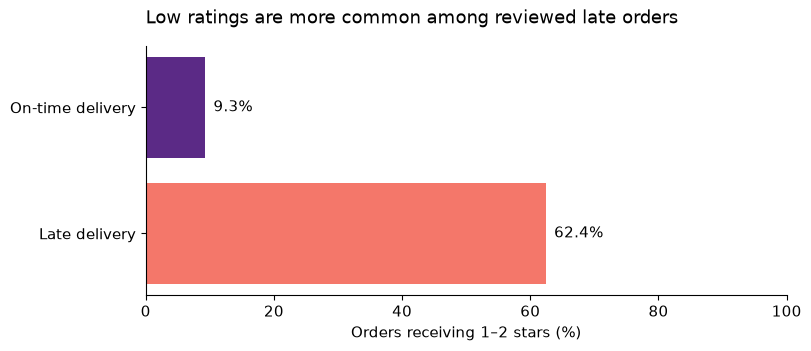

on_time: 8,289 low reviews / 89,443 reviewed orders
late: 3,983 low reviews / 6,381 reviewed orders


In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False})
colors = ['#5b2a86','#f4776a']
groups = result['delivery_groups']
fig, ax = plt.subplots(figsize=(8,3.4),layout='constrained')
values = [r['low_review_rate'] for r in groups]
bars = ax.barh(['On-time delivery','Late delivery'], values, color=colors)
ax.invert_yaxis(); ax.set_xlim(0,100); ax.set_xlabel('Orders receiving 1–2 stars (%)')
ax.set_title('Low ratings are more common among reviewed late orders',loc='left',pad=16)
ax.bar_label(bars,labels=[f'{v:.1f}%' for v in values],padding=6)
plt.show()
for r in groups:
    print(f"{r['group']}: {r['low_reviews']:,} low reviews / {r['reviewed_orders']:,} reviewed orders")

The association is strong, but ratings reflect the entire purchase experience. Survey timing and response patterns can differ. A proactive-support pilot is a proposed response, not an improvement measured here.

### 2. Elapsed delivery stages
Use the same 95,082 records across the stages so their means add to the mean total duration. The remaining 1,388 eligible records have missing or out-of-sequence stage dates.

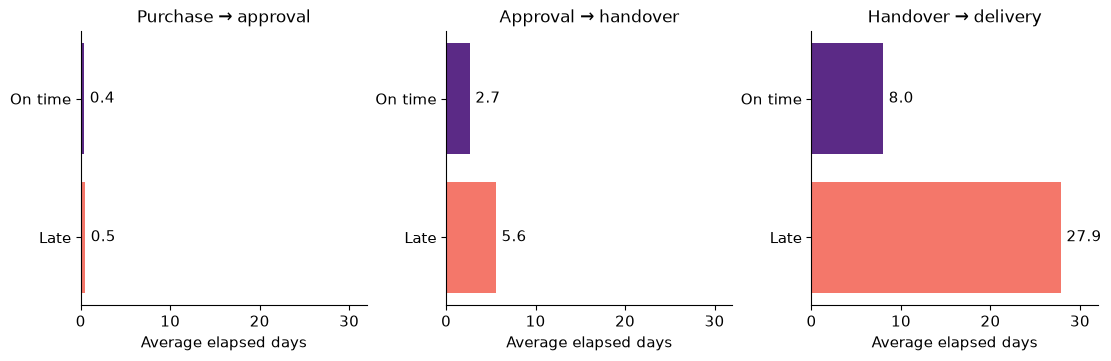

on_time: 88,573 orders, 11.1 mean total days
late: 6,509 orders, 34.0 mean total days


In [3]:
stage_groups=result['stages']
fig, axes=plt.subplots(1,3,figsize=(11,3.5),layout='constrained',sharex=True)
for ax,key,title in zip(axes,['approval_days','handover_days','transit_days'],['Purchase → approval','Approval → handover','Handover → delivery']):
    values=[r[key] for r in stage_groups]
    bars=ax.barh(['On time','Late'],values,color=colors)
    ax.invert_yaxis();ax.set_xlim(0,32);ax.set_xlabel('Average elapsed days');ax.set_title(title,fontsize=12)
    ax.bar_label(bars,labels=[f'{v:.1f}' for v in values],padding=4)
plt.show()
for r in stage_groups:
    assert abs(r['approval_days']+r['handover_days']+r['transit_days']-r['total_days']) < 1e-9
    print(f"{r['group']}: {r['orders']:,} orders, {r['total_days']:.1f} mean total days")

The interval after handover is longest for late orders. This locates recorded elapsed time; it does not prove a carrier caused the delay. Tracking scans and incident records would help distinguish transport, sorting, waiting and failed attempts.

### 3. Destination priority: count and rate
Select the five states with the most late orders, then show each destination's rate with its denominator. State is the customer's destination, not the seller's location.

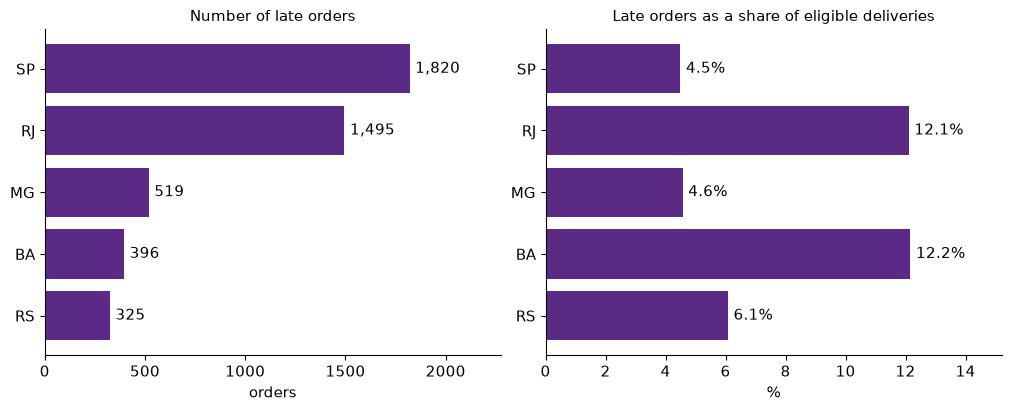

SP: 1,820 late / 40,494 eligible = 4.5%
RJ: 1,495 late / 12,350 eligible = 12.1%
MG: 519 late / 11,354 eligible = 4.6%
BA: 396 late / 3,256 eligible = 12.2%
RS: 325 late / 5,344 eligible = 6.1%


In [4]:
states=sorted(result['states'], key=lambda r:r['late_orders'],reverse=True)[:5]
fig,axes=plt.subplots(1,2,figsize=(10,4),layout='constrained')
for ax,key,title,unit in zip(axes,['late_orders','late_rate'],['Number of late orders','Late orders as a share of eligible deliveries'],['orders','%']):
    values=[r[key] for r in states]
    bars=ax.barh([r['group'] for r in states],values,color='#5b2a86')
    ax.invert_yaxis(); ax.set_xlim(0,max(values)*1.25);ax.set_xlabel(unit);ax.set_title(title,fontsize=11)
    ax.bar_label(bars,labels=[f'{v:,.0f}' if key=='late_orders' else f'{v:.1f}%' for v in values],padding=4)
plt.show()
for r in states:
    print(f"{r['group']}: {r['late_orders']:,} late / {r['orders']:,} eligible = {r['late_rate']:.1f}%")

SP = São Paulo; RJ = Rio de Janeiro; MG = Minas Gerais; BA = Bahia; RS = Rio Grande do Sul. Rio has fewer eligible orders than São Paulo but a higher late rate. Neither comparison adjusts for seller, route, category or month mix; use it to prioritise an investigation, not assign blame.

### 4. Review sensitivity and source-quality checks

In [5]:
for r in result['single_review_sensitivity']:
    print(f"Exactly one review — {r['group']}: {r['low_review_rate']:.1f}% low ratings across {r['orders']:,} orders")
q=result['quality']
assert all(q[k]==0 for k in q if k.startswith(('duplicate','orphan')))
assert sum(r['orders'] for r in result['states'])==result['overall']['orders']
assert sum(result['statuses'].values())==q['rows']['orders']
print('Relevant primary keys and foreign keys pass; state and status totals reconcile.')
print('Stage exclusions:',q['stage_exclusions'])

Exactly one review — on_time: 9.2% low ratings across 88,946 orders
Exactly one review — late: 62.4% low ratings across 6,353 orders
Relevant primary keys and foreign keys pass; state and status totals reconcile.
Stage exclusions: {'out_of_sequence_stage_dates': 1373, 'missing_stage_dates': 15}


## Takeaways
- Begin with a focused review of late-order journeys in Rio, retaining São Paulo on a volume watchlist.
- Propose a shared overdue-order queue with one row per order, visible unknowns and count-plus-rate comparisons.
- Test customer communication through a measured pilot before claiming impact.

See [business brief](docs/business-brief.md) for proposed requirements and acceptance criteria. No inventory, stockout, carrier-fault, savings or realised-improvement claims are supported.

**Learning prompt:** Why would ranking destinations only by the number of late orders produce a different priority from ranking by late rate? Use São Paulo and Rio to explain both sides.